## CapStone Project
# Final Code (End-To-End Pipeline)
## Technical Implementation
### By: Chuck Akomah Munyah-Asaah
#### July 2026¶


In [40]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [41]:
# =========================
# WEEKLY AGGREGATION (PRODUCT-NAME LEVEL)
# =========================

# Load + clean
df = pd.read_csv('walmart.csv')
df.columns = df.columns.str.strip().str.lower()

# Convert date
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['week'] = df['transaction_date'].dt.to_period('W').apply(lambda r: r.start_time)

# =========================
# CLEAN PRODUCT IDENTIFIER (IMPORTANT)
# =========================
df['product_name'] = df['product_name'].str.strip()

# =========================
# WEEKLY AGGREGATION
# =========================
weekly_df = df.groupby(['week', 'product_name']).agg({
    'quantity_sold': 'sum',
    'promotion_applied': 'max',
    'holiday_indicator': 'max'
}).reset_index()

# Rename target
weekly_df.rename(columns={'quantity_sold': 'demand'}, inplace=True)

# Copy
final_df = weekly_df.copy()

# Convert boolean → numeric
final_df['promotion_applied'] = final_df['promotion_applied'].astype(int)
final_df['holiday_indicator'] = final_df['holiday_indicator'].astype(int)

# Remove zero demand
final_df = final_df[final_df['demand'] > 0].reset_index(drop=True)

# Inspect
print(final_df.shape)
final_df.head()

(304, 5)


,week,product_name,demand,promotion_applied,holiday_indicator
0,2024-01-01,Camera,40,1,1
1,2024-01-01,Fridge,53,1,1
2,2024-01-01,Headphones,47,1,1
3,2024-01-01,Laptop,40,1,1
4,2024-01-01,Smartphone,60,1,1


In [42]:
# =========================
# 1. FEATURE ENGINEERING FUNCTION (PRODUCT-NAME LEVEL)
# =========================
def create_features(df):

    # Sort by product_name and time
    df = df.sort_values(by=['product_name', 'week']).copy()

    # Time features
    df['weekofyear'] = df['week'].dt.isocalendar().week.astype(int)
    df['month'] = df['week'].dt.month

    # Lag features (PRODUCT-NAME LEVEL)
    df['lag_1'] = df.groupby('product_name')['demand'].shift(1)
    df['lag_2'] = df.groupby('product_name')['demand'].shift(2)
    df['lag_4'] = df.groupby('product_name')['demand'].shift(4)

    # Rolling means (PRODUCT-NAME LEVEL)
    df['rolling_mean_2'] = (
        df.groupby('product_name')['demand']
        .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())
    )

    df['rolling_mean_4'] = (
        df.groupby('product_name')['demand']
        .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
    )

    # Drop rows where lag features are missing
    df = df.dropna(subset=['lag_1', 'lag_2'])

    print(f"Rows after feature engineering: {len(df)}")

    return df.reset_index(drop=True)


# Apply features
final_df = create_features(final_df)

# =========================
# 2. DEFINE FEATURES
# =========================
features = [
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_2', 'rolling_mean_4',
    'promotion_applied',
    'holiday_indicator',
    'weekofyear',
    'month'
]

target = 'demand'

# =========================
# 3. REMOVE DUPLICATES (UPDATED)
# =========================
final_df = final_df.drop_duplicates(
    subset=['product_name', 'week']
).reset_index(drop=True)

# Final clean
final_df = final_df.dropna().reset_index(drop=True)

Rows after feature engineering: 288


In [43]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd

# =========================
# PRODUCT-LEVEL ARIMA
# =========================

arima_results = []

for pname in final_df['product_name'].unique():

    df_p = final_df[final_df['product_name'] == pname].sort_values('week')

    # Create time series
    ts = df_p.set_index('week')['demand'].asfreq('W-MON')

    # Skip very small series
    if len(ts.dropna()) < 10:
        continue

    split = int(len(ts) * 0.7)
    train = ts[:split]
    test = ts[split:]

    try:
        model = ARIMA(
            train,
            order=(2,1,2),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        model_fit = model.fit()

        forecast = model_fit.forecast(steps=len(test))

        # Evaluation
        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mean_squared_error(test, forecast))
        mape = np.mean(np.abs((test - forecast) / (test + 1e-8))) * 100

        arima_results.append({
            'product_name': pname,
            'MAE': mae,
            'RMSE': rmse,
            'MAPE': mape
        })

    except:
        continue

# Convert to dataframe
arima_df = pd.DataFrame(arima_results)

# =========================
# SUMMARY RESULTS
# =========================

print("ARIMA Results per Product:")
print(arima_df.head())

print("\nAverage ARIMA Performance:")
print(arima_df.mean(numeric_only=True).round(3))

ARIMA Results per Product:
  product_name        MAE       RMSE        MAPE
0       Camera  17.140039  23.032351  555.920756
1       Fridge  17.788552  22.552081   46.865074
2   Headphones  12.499578  17.933573  227.205708
3       Laptop  17.382742  21.011353  165.305076
4   Smartphone  17.614824  20.962036  236.718873

Average ARIMA Performance:
MAE      15.599
RMSE     19.900
MAPE    176.227
dtype: float64


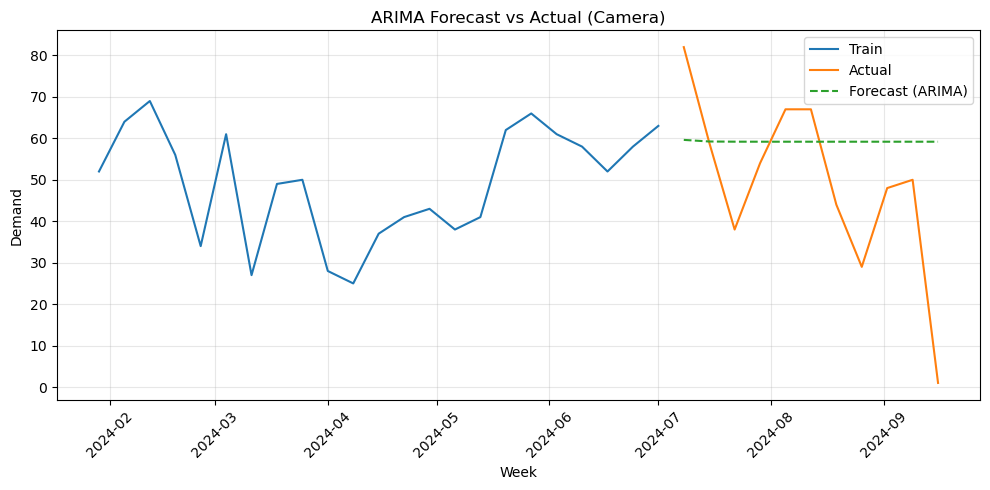

In [44]:
# =========================
# ARIMA FORECAST PLOT (PER PRODUCT)
# =========================

import matplotlib.pyplot as plt

# Pick a representative product (first or top demand)
product_to_plot = final_df['product_name'].unique()[0]

df_p = final_df[final_df['product_name'] == product_to_plot].sort_values('week')

ts = df_p.set_index('week')['demand'].asfreq('W-MON')

# Train-test split
split = int(len(ts) * 0.7)
train = ts[:split]
test = ts[split:]

# Fit ARIMA
model = ARIMA(
    train,
    order=(2,1,2),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast, linestyle='--', label="Forecast (ARIMA)")

plt.title(f"ARIMA Forecast vs Actual ({product_to_plot})")
plt.xlabel("Week")
plt.ylabel("Demand")

plt.legend()
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [45]:
# =========================
# STEP 1: SORT PROPERLY
# =========================
final_df = final_df.sort_values(by=['product_name', 'week']).reset_index(drop=True)

train_list = []
test_list = []

# =========================
# STEP 2: TIME-SERIES SPLIT PER PRODUCT
# =========================
for pname in final_df['product_name'].unique():
    
    df_p = final_df[final_df['product_name'] == pname].copy()
    
    split_index = int(len(df_p) * 0.7)
    
    # Ensure at least 1 row in test
    if len(df_p) - split_index == 0:
        split_index = len(df_p) - 1
    
    train_list.append(df_p.iloc[:split_index])
    test_list.append(df_p.iloc[split_index:])

# Combine all products
train = pd.concat(train_list).reset_index(drop=True)
test = pd.concat(test_list).reset_index(drop=True)

# =========================
# STEP 3: CLEAN
# =========================
train = train.dropna().reset_index(drop=True)
test = test.dropna().reset_index(drop=True)

# =========================
# STEP 4: SAFETY CHECKS
# =========================
assert len(train) > 0, "Train set is empty — check pipeline"
assert len(test) > 0, "Test set is empty — check pipeline"

# =========================
# STEP 5: CREATE X AND y
# =========================
X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# =========================
# STEP 6: DEBUG / VALIDATION
# =========================
print("TRAIN SAMPLE:")
print(train[['product_name','week','demand']].head())

print("\nTEST SAMPLE:")
print(test[['product_name','week','demand']].head())

print("\nTRAIN SIZE:", len(train))
print("TEST SIZE:", len(test))

# =========================
# STEP 7: MISSING VALUES CHECK
# =========================
print("\nMissing values check:")
print(X_train.isnull().sum())

# =========================
# STEP 8: DUPLICATE CHECK
# =========================
common = pd.merge(train, test, how='inner', on=['product_name','week'])
print("\nNumber of overlapping rows:", len(common))


TRAIN SAMPLE:
  product_name       week  demand
0       Camera 2024-01-29      52
1       Camera 2024-02-05      64
2       Camera 2024-02-12      69
3       Camera 2024-02-19      56
4       Camera 2024-02-26      34

TEST SAMPLE:
  product_name       week  demand
0       Camera 2024-07-08      82
1       Camera 2024-07-15      59
2       Camera 2024-07-22      38
3       Camera 2024-07-29      54
4       Camera 2024-08-05      67

TRAIN SIZE: 184
TEST SIZE: 88

Missing values check:
lag_1                0
lag_2                0
lag_4                0
rolling_mean_2       0
rolling_mean_4       0
promotion_applied    0
holiday_indicator    0
weekofyear           0
month                0
dtype: int64

Number of overlapping rows: 0


In [46]:
# =========================
# MODEL TRAINING + EVALUATION (UPDATED)
# =========================

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# =========================
# DEFINE EVALUATION FUNCTION
# =========================
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Avoid division by zero
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    
    return round(mae,3), round(rmse,3), round(mape,3)

# =========================
# 1. LINEAR REGRESSION
# =========================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

# =========================
# 2. RANDOM FOREST (TUNED SLIGHTLY)
# =========================
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

# =========================
# 3. XGBOOST (TUNED)
# =========================
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

# =========================
# 4. EVALUATE ALL MODELS
# =========================
results = {
    "Linear Regression": evaluate(y_test, y_pred_lr),
    "Random Forest": evaluate(y_test, y_pred_rf),
    "XGBoost": evaluate(y_test, y_pred_xgb)
}

# =========================
# 5. CREATE RESULTS TABLE
# =========================
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "MAPE (%)"]).T

print("\nMODEL PERFORMANCE COMPARISON:\n")
print(results_df)


MODEL PERFORMANCE COMPARISON:

                      MAE    RMSE  MAPE (%)
Linear Regression  14.374  18.828   161.311
Random Forest      15.813  20.828   187.203
XGBoost            17.384  22.229   190.699


In [47]:
# =========================
# 7. FORECAST ERROR & UNCERTAINTY (PRODUCT-LEVEL)
# =========================

# Use best model (update if needed)
y_pred = y_pred_lr  # or y_pred_rf / y_pred_xgb based on best model

# Create a working dataframe
results_df = test.copy()
results_df['prediction'] = y_pred

# Compute errors
results_df['error'] = results_df['demand'] - results_df['prediction']

# Compute uncertainty per product
sigma_df = results_df.groupby('product_name')['error'].std().reset_index()
sigma_df.rename(columns={'error': 'sigma'}, inplace=True)

# Merge back
results_df = results_df.merge(sigma_df, on='product_name', how='left')

print("Sample Uncertainty (σ per product):")
print(sigma_df.head())

# =========================
# 8. SAFETY STOCK (PRODUCT-LEVEL)
# =========================

z = 1.65  # 95% service level

results_df['safety_stock'] = z * results_df['sigma']

# =========================
# 9. INVENTORY DECISION
# =========================

results_df['inventory_level'] = results_df['prediction'] + results_df['safety_stock']

# =========================
# 10. COST FUNCTION
# =========================

h = 1  # holding cost
c = 5  # stockout cost

results_df['holding_cost'] = np.maximum(
    results_df['inventory_level'] - results_df['demand'], 0
) * h

results_df['stockout_cost'] = np.maximum(
    results_df['demand'] - results_df['inventory_level'], 0
) * c

results_df['total_cost'] = results_df['holding_cost'] + results_df['stockout_cost']

# =========================
# SUMMARY METRICS
# =========================

print("\nAverage Cost:", round(results_df['total_cost'].mean(), 3))
print("Average Safety Stock:", round(results_df['safety_stock'].mean(), 3))

Sample Uncertainty (σ per product):
  product_name      sigma
0       Camera  20.779550
1       Fridge  20.207555
2   Headphones  18.402553
3       Laptop  19.088777
4   Smartphone  20.115828

Average Cost: 33.029
Average Safety Stock: 31.561


### Demand Trend

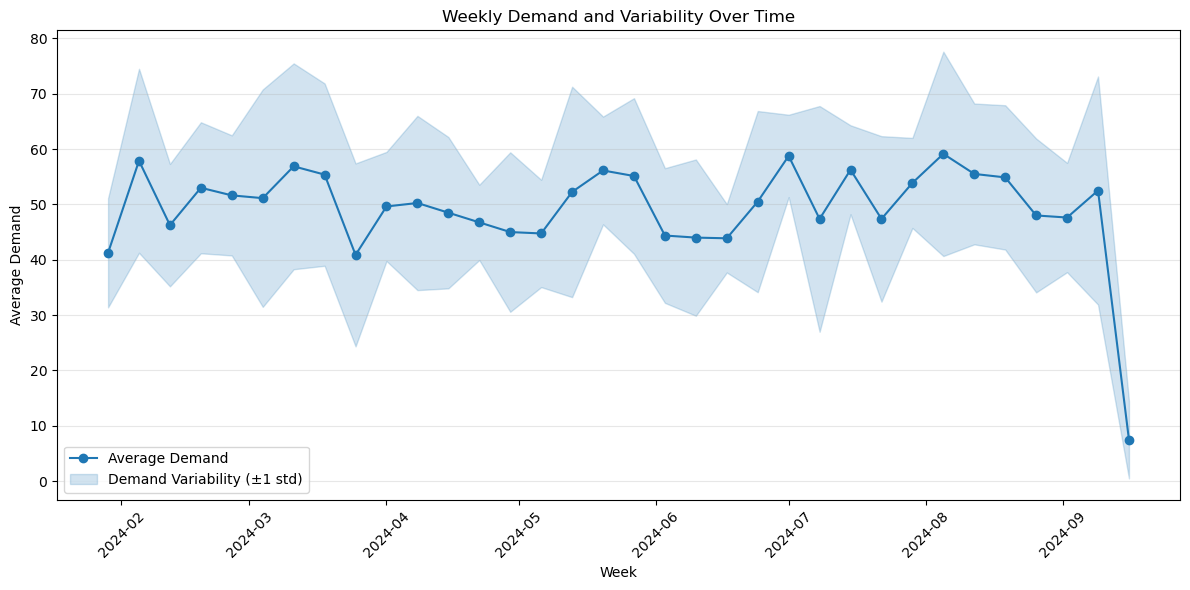

In [49]:
# =========================
# DEMAND VARIABILITY PLOT (FINAL VERSION)
# =========================

import matplotlib.pyplot as plt
import pandas as pd

# =========================
# PREPARE DATA
# =========================

# Ensure week is datetime (VERY IMPORTANT for proper plotting)
weekly_stats = final_df.copy()
weekly_stats['week'] = pd.to_datetime(weekly_stats['week'])

# Aggregate mean and std per week
weekly_stats = weekly_stats.groupby('week')['demand'].agg(['mean','std']).reset_index()

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,6))

# Plot mean demand (consistent color)
plt.plot(
    weekly_stats['week'], 
    weekly_stats['mean'],
    marker='o',
    linestyle='-',
    color='#1f77b4',
    label='Average Demand'
)

# Variability band (± std)
plt.fill_between(
    weekly_stats['week'],
    weekly_stats['mean'] - weekly_stats['std'],
    weekly_stats['mean'] + weekly_stats['std'],
    color='#1f77b4',
    alpha=0.2,
    label='Demand Variability (±1 std)'
)

# =========================
# LABELS (UPDATED FOR CONSISTENCY)
# =========================

plt.title("Weekly Demand and Variability Over Time")
plt.xlabel("Week")
plt.ylabel("Average Demand")

# Grid
plt.grid(axis='y', alpha=0.3)

# Legend
plt.legend()

# Rotate x-axis
plt.xticks(rotation=45)

# Layout
plt.tight_layout()

# Show
plt.show()

### Forecast vs Actual

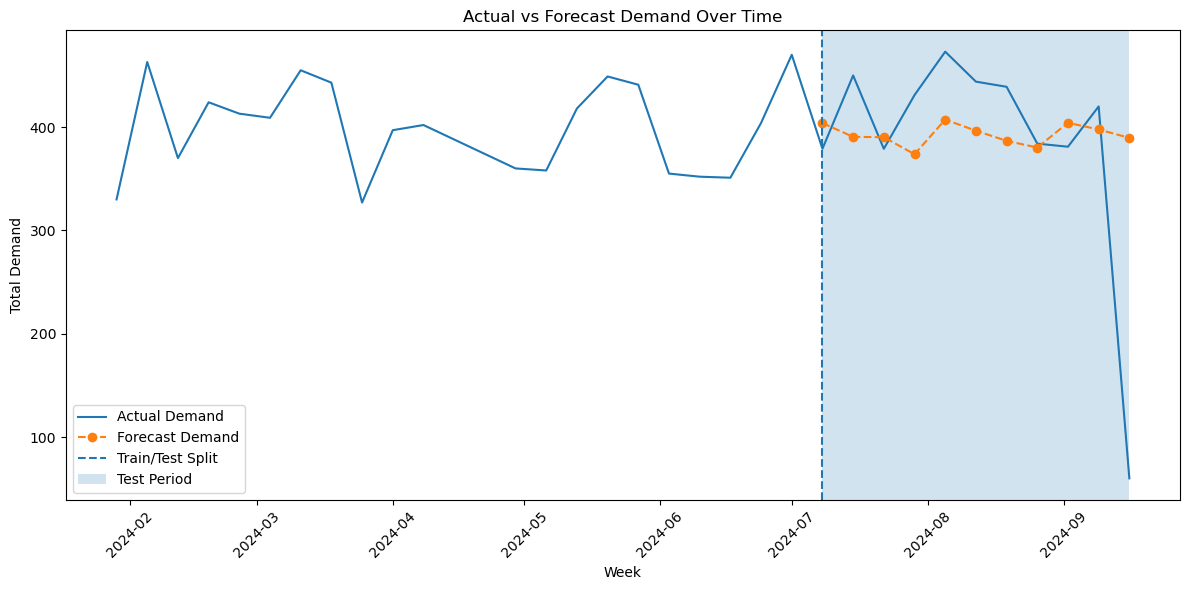

In [50]:
# =========================
# AGGREGATE FOR PLOTTING
# =========================

# Actual demand (full timeline)
actual_weekly = final_df.groupby('week')['demand'].sum().reset_index()

# Predictions (test only)
results_df = test.copy()
results_df['prediction'] = y_pred_lr

pred_weekly = results_df.groupby('week')['prediction'].sum().reset_index()

# =========================
# ALIGN PREDICTIONS WITH ACTUAL
# =========================

# Merge for proper alignment
plot_df = actual_weekly.merge(pred_weekly, on='week', how='left')

# =========================
# PLOT
# =========================

plt.figure(figsize=(12,6))

# Plot actual demand
plt.plot(
    plot_df['week'],
    plot_df['demand'],
    label='Actual Demand'
)

# Plot forecast (only where available)
plt.plot(
    plot_df['week'],
    plot_df['prediction'],
    linestyle='--',
    marker='o',
    label='Forecast Demand'
)

# Train/Test split
split_date = pred_weekly['week'].min()

plt.axvline(
    x=split_date,
    linestyle='--',
    label='Train/Test Split'
)

# Shade test region
plt.axvspan(
    split_date,
    plot_df['week'].max(),
    alpha=0.2,
    label='Test Period'
)

# Labels
plt.title("Actual vs Forecast Demand Over Time")
plt.xlabel("Week")
plt.ylabel("Total Demand")

# Formatting
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Demand vs Inventory Level

In [51]:
# =========================
# REBUILD RESULTS DATAFRAME (FULL PIPELINE)
# =========================

# Choose best model prediction
y_pred = y_pred_lr   # change if needed

# Create results_df
results_df = test.copy()
results_df['prediction'] = y_pred

# =========================
# FORECAST ERROR
# =========================
results_df['error'] = results_df['demand'] - results_df['prediction']

# =========================
# UNCERTAINTY (σ per product)
# =========================
sigma_df = results_df.groupby('product_name')['error'].std().reset_index()
sigma_df.rename(columns={'error': 'sigma'}, inplace=True)

# Merge back
results_df = results_df.merge(sigma_df, on='product_name', how='left')

# =========================
# SAFETY STOCK
# =========================
z = 1.65
results_df['safety_stock'] = z * results_df['sigma']

# =========================
# INVENTORY DECISION
# =========================
results_df['inventory_level'] = results_df['prediction'] + results_df['safety_stock']

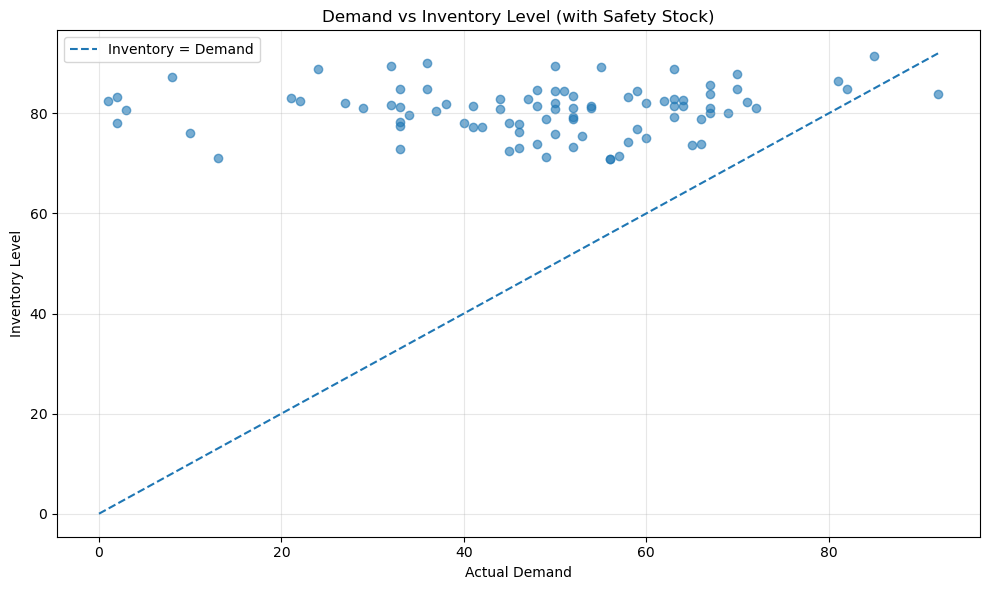

In [52]:
plt.figure(figsize=(10,6))

plt.scatter(
    results_df['demand'],
    results_df['inventory_level'],
    alpha=0.6
)

max_val = max(
    results_df['demand'].max(),
    results_df['inventory_level'].max()
)

plt.plot(
    [0, max_val],
    [0, max_val],
    linestyle='--',
    label='Inventory = Demand'
)

plt.xlabel("Actual Demand")
plt.ylabel("Inventory Level")
plt.title("Demand vs Inventory Level (with Safety Stock)")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Demand vs. Inventory Level by Product

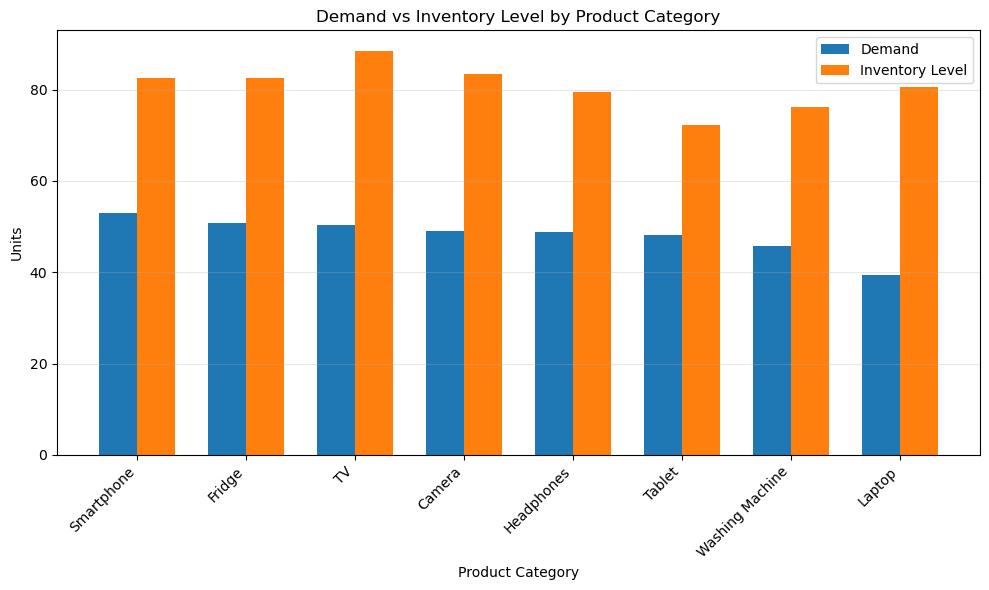

In [53]:
# =========================
# DEMAND vs INVENTORY LEVEL BY PRODUCT CATEGORY (FINAL)
# =========================

import matplotlib.pyplot as plt
import numpy as np

# =========================
# BUILD RESULTS DATAFRAME
# =========================

results_df = test.copy()
results_df['prediction'] = y_pred_lr

# Compute error
results_df['error'] = results_df['demand'] - results_df['prediction']

# =========================
# PRODUCT-LEVEL UNCERTAINTY
# =========================

sigma_df = results_df.groupby('product_name')['error'].std().reset_index()
sigma_df.rename(columns={'error': 'sigma'}, inplace=True)

# Merge back
results_df = results_df.merge(sigma_df, on='product_name', how='left')

# =========================
# SAFETY STOCK
# =========================

z = 1.65
results_df['safety_stock'] = z * results_df['sigma']

# =========================
# INVENTORY DECISION
# =========================

results_df['inventory_level'] = results_df['prediction'] + results_df['safety_stock']

# =========================
# AGGREGATE BY PRODUCT CATEGORY (FIXED)
# =========================

product_summary = results_df.groupby('product_name').agg({
    'demand': 'mean',              # <-- FIXED (was sum)
    'inventory_level': 'mean'      # <-- FIXED
}).reset_index()

# Sort for clean display
product_summary = product_summary.sort_values(by='demand', ascending=False)

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

x = np.arange(len(product_summary))
width = 0.35

# Bars
plt.bar(x - width/2, product_summary['demand'],
        width=width, color='#1f77b4', label='Demand')

plt.bar(x + width/2, product_summary['inventory_level'],
        width=width, color='#ff7f0e', label='Inventory Level')

# Labels
plt.xticks(x, product_summary['product_name'], rotation=45, ha='right')
plt.xlabel("Product Category")
plt.ylabel("Units")
plt.title("Demand vs Inventory Level by Product Category")

# Grid
plt.grid(axis='y', alpha=0.3)

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Show
plt.show()

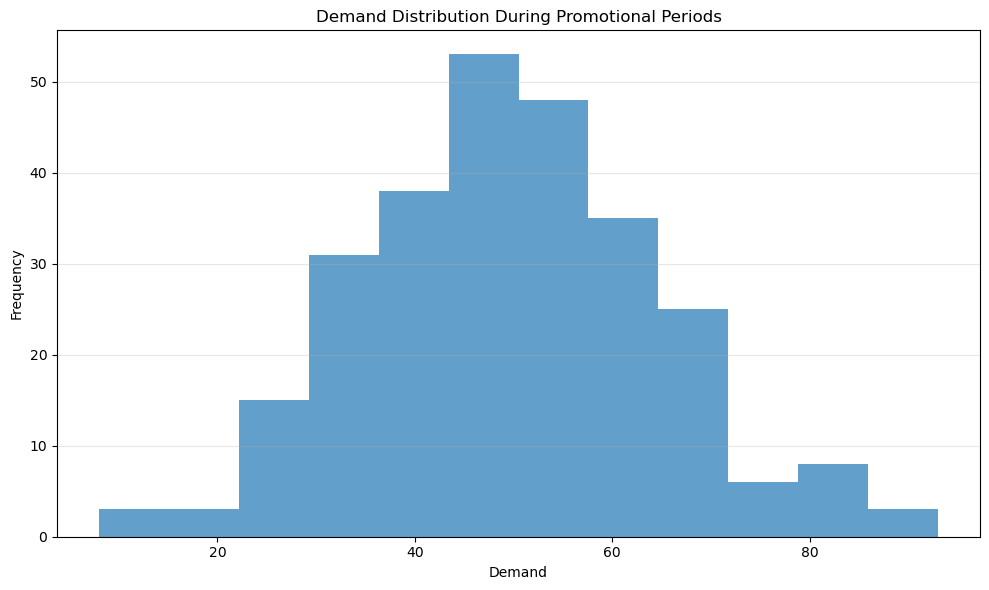

In [54]:
# =========================
# DEMAND DISTRIBUTION DURING PROMOTIONAL PERIODS
# =========================

import matplotlib.pyplot as plt

# =========================
# FILTER PROMOTIONAL DATA
# =========================

# Keep only rows where promotion was applied
promo_df = final_df[final_df['promotion_applied'] == 1]

# =========================
# PLOT HISTOGRAM
# =========================

plt.figure(figsize=(10,6))

plt.hist(
    promo_df['demand'],
    bins=12,                # similar binning as your chart
    color='#1f77b4',        # consistent blue color
    alpha=0.7
)

# Labels
plt.title("Demand Distribution During Promotional Periods")
plt.xlabel("Demand")
plt.ylabel("Frequency")

# Grid
plt.grid(axis='y', alpha=0.3)

# Remove legend (important fix)
# plt.legend()  <-- DO NOT include

# Layout
plt.tight_layout()

# Show
plt.show()

### Cost Distribution

In [55]:
# =========================
# REBUILD RESULTS PIPELINE (FULLY SAFE)
# =========================

# Step 1: create results_df fresh
results_df = test.copy()
results_df['prediction'] = y_pred_lr

# Step 2: compute error
results_df['error'] = results_df['demand'] - results_df['prediction']

# Step 3: compute sigma per product
sigma_df = results_df.groupby('product_name')['error'].std().reset_index()
sigma_df.columns = ['product_name', 'sigma']

# Step 4: merge safely
results_df = results_df.merge(sigma_df, on='product_name', how='left')

# Step 5: verify merge worked
print("Columns after merge:", results_df.columns)

# Step 6: safety stock
z = 1.65
results_df['safety_stock'] = z * results_df['sigma']

# Step 7: inventory
results_df['inventory_level'] = results_df['prediction'] + results_df['safety_stock']

# Step 8: cost
h = 1
c = 5

results_df['holding_cost'] = np.maximum(
    results_df['inventory_level'] - results_df['demand'], 0
) * h

results_df['stockout_cost'] = np.maximum(
    results_df['demand'] - results_df['inventory_level'], 0
) * c

results_df['total_cost'] = results_df['holding_cost'] + results_df['stockout_cost']

Columns after merge: Index(['week', 'product_name', 'demand', 'promotion_applied',
       'holiday_indicator', 'weekofyear', 'month', 'lag_1', 'lag_2', 'lag_4',
       'rolling_mean_2', 'rolling_mean_4', 'prediction', 'error', 'sigma'],
      dtype='object')


In [56]:
print(results_df[['product_name', 'sigma']].head())

  product_name     sigma
0       Camera  20.77955
1       Camera  20.77955
2       Camera  20.77955
3       Camera  20.77955
4       Camera  20.77955


In [57]:
import numpy as np

# =========================
# COST CALCULATION (MISSING STEP)
# =========================
h = 1   # holding cost
c = 5   # stockout cost

results_df['holding_cost'] = np.maximum(
    results_df['inventory_level'] - results_df['demand'], 0
) * h

results_df['stockout_cost'] = np.maximum(
    results_df['demand'] - results_df['inventory_level'], 0
) * c

results_df['total_cost'] = results_df['holding_cost'] + results_df['stockout_cost']

# Debug check
print("Columns now:", results_df.columns)

Columns now: Index(['week', 'product_name', 'demand', 'promotion_applied',
       'holiday_indicator', 'weekofyear', 'month', 'lag_1', 'lag_2', 'lag_4',
       'rolling_mean_2', 'rolling_mean_4', 'prediction', 'error', 'sigma',
       'safety_stock', 'inventory_level', 'holding_cost', 'stockout_cost',
       'total_cost'],
      dtype='object')


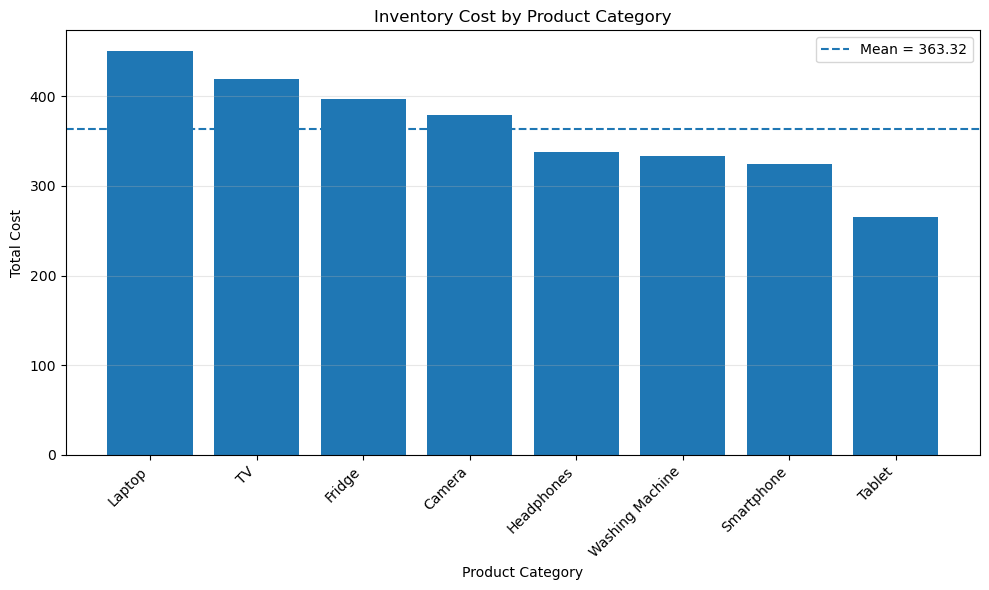

In [58]:
# =========================
# COST BY PRODUCT (WORKS NOW)
# =========================

cost_summary = results_df.groupby('product_name')['total_cost'].sum().reset_index()

cost_summary = cost_summary.sort_values(by='total_cost', ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    cost_summary['product_name'],
    cost_summary['total_cost']
)

mean_cost = cost_summary['total_cost'].mean()
plt.axhline(mean_cost, linestyle='--', label=f'Mean = {mean_cost:.2f}')

plt.title("Inventory Cost by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Cost")

plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Top Cost Product

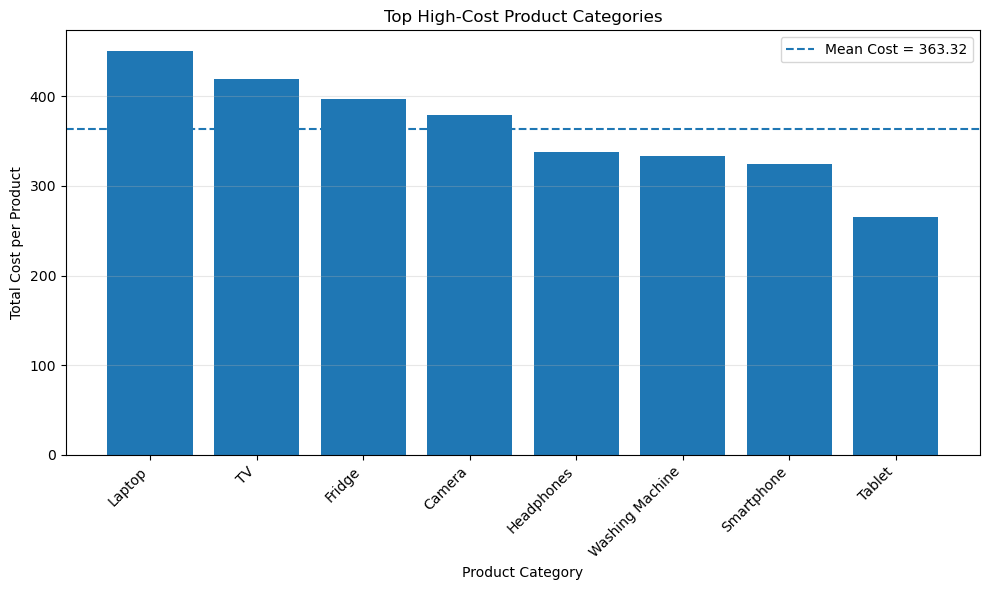

In [59]:
# =========================
# TOP HIGH-COST PRODUCTS (FINAL)
# =========================

import matplotlib.pyplot as plt

# =========================
# AGGREGATE COST PER PRODUCT
# =========================

product_cost = results_df.groupby('product_name')['total_cost'].sum().reset_index()

# Top 10 products
top_cost = product_cost.nlargest(10, 'total_cost')

# Mean cost
mean_cost = product_cost['total_cost'].mean()

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

plt.bar(
    top_cost['product_name'],
    top_cost['total_cost']
)

# Mean line
plt.axhline(
    mean_cost,
    linestyle='--',
    label=f'Mean Cost = {mean_cost:.2f}'
)

# Labels
plt.title("Top High-Cost Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Total Cost per Product")

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Grid + legend
plt.grid(axis='y', alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

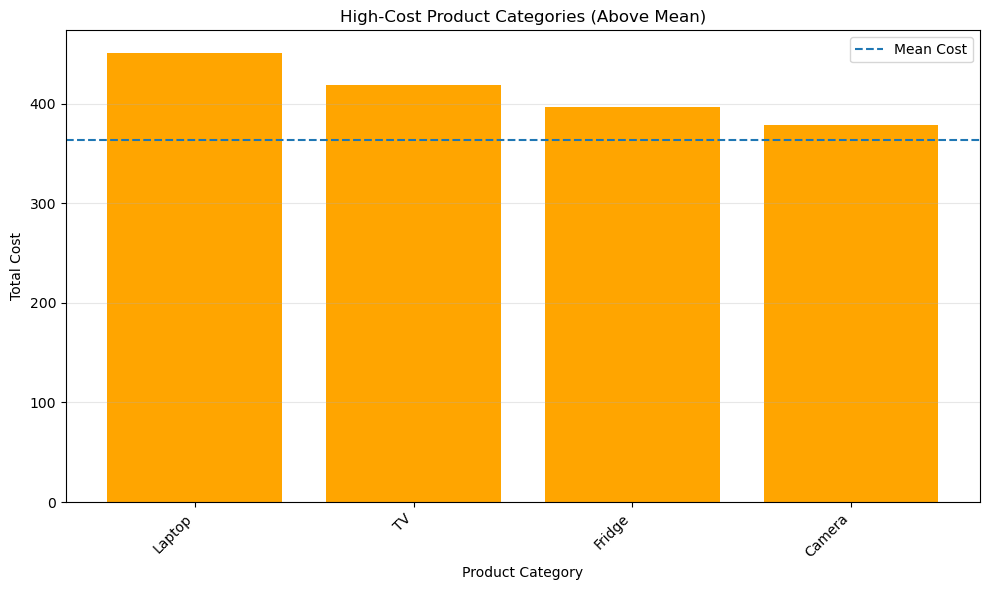

In [60]:
import matplotlib.pyplot as plt

# =========================
# AGGREGATE COST PER PRODUCT
# =========================
product_cost = results_df.groupby('product_name')['total_cost'].sum().reset_index()

# Compute mean cost
mean_cost = product_cost['total_cost'].mean()

# =========================
# FILTER ONLY ABOVE MEAN
# =========================
top_cost = product_cost[product_cost['total_cost'] > mean_cost]

# Sort descending
top_cost = top_cost.sort_values(by='total_cost', ascending=False)

# =========================
# PLOT
# =========================
plt.figure(figsize=(10,6))

plt.bar(
    top_cost['product_name'],
    top_cost['total_cost'],
    color='orange'
)

# Mean line
plt.axhline(mean_cost, linestyle='--', label='Mean Cost')

# Labels
plt.title("High-Cost Product Categories (Above Mean)")
plt.xlabel("Product Category")
plt.ylabel("Total Cost")

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Grid
plt.grid(axis='y', alpha=0.3)

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Show
plt.show()

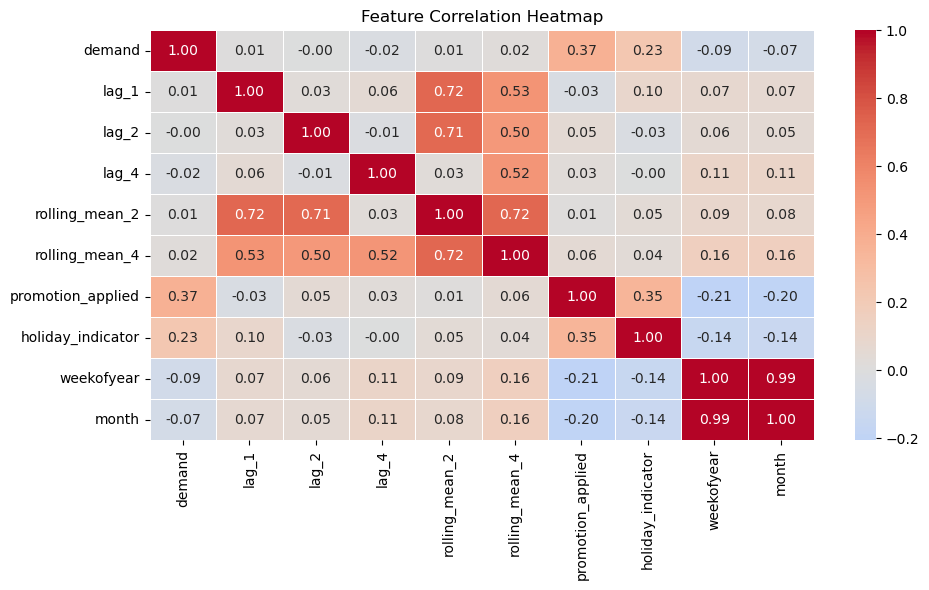

In [61]:
# =========================
# FEATURE CORRELATION HEATMAP (FINAL)
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

# Select features (FULL set)
cols = [
    'demand', 
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_2', 'rolling_mean_4',
    'promotion_applied', 
    'holiday_indicator',
    'weekofyear',
    'month'
]

# Compute correlation
corr = final_df[cols].corr()

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",            # cleaner numbers
    cmap='coolwarm',
    center=0,             # highlight positive/negative
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

Promotion distribution:
promotion_label
Promotion       268
No Promotion      4
Name: count, dtype: int64


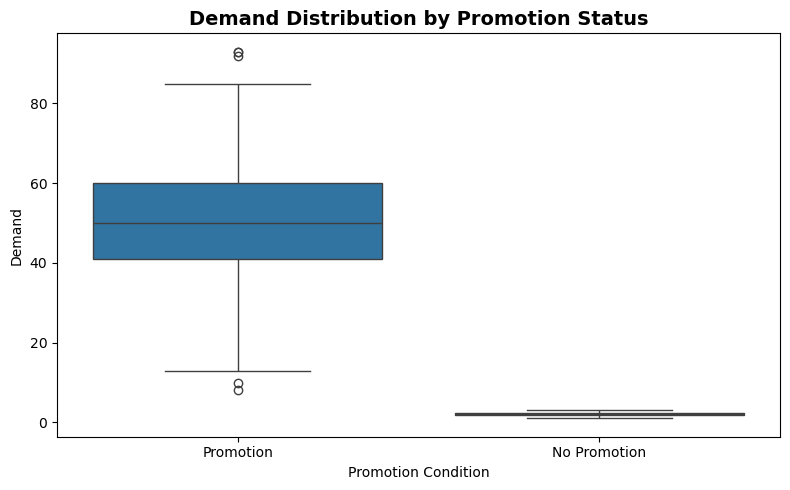

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# PREPARE DATA
# -----------------------------
plot_df = final_df.copy()

# Ensure numeric
plot_df['promotion_applied'] = plot_df['promotion_applied'].astype(int)

# Create labels
plot_df['promotion_label'] = plot_df['promotion_applied'].map({
    0: 'No Promotion',
    1: 'Promotion'
})

# -----------------------------
# CHECK CLASS DISTRIBUTION
# -----------------------------
print("Promotion distribution:")
print(plot_df['promotion_label'].value_counts())

# -----------------------------
# HANDLE SINGLE-CLASS CASE (CORRECT WAY)
# -----------------------------
if plot_df['promotion_label'].nunique() < 2:
    print("⚠ Only one promotion class found — boxplot not meaningful")

    plt.figure(figsize=(6,4))
    plt.hist(plot_df['demand'], bins=10, alpha=0.7)

    plt.title("Demand Distribution (Single Promotion Class)")
    plt.xlabel("Demand")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

else:
    # -----------------------------
    # CREATE BOXPLOT (BEST PRACTICE)
    # -----------------------------
    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=plot_df,
        x='promotion_label',
        y='demand'
    )

    # -----------------------------
    # TITLES AND LABELS
    # -----------------------------
    plt.title("Demand Distribution by Promotion Status", fontsize=14, weight='bold')
    plt.xlabel("Promotion Condition")
    plt.ylabel("Demand")

    plt.tight_layout()
    plt.show()

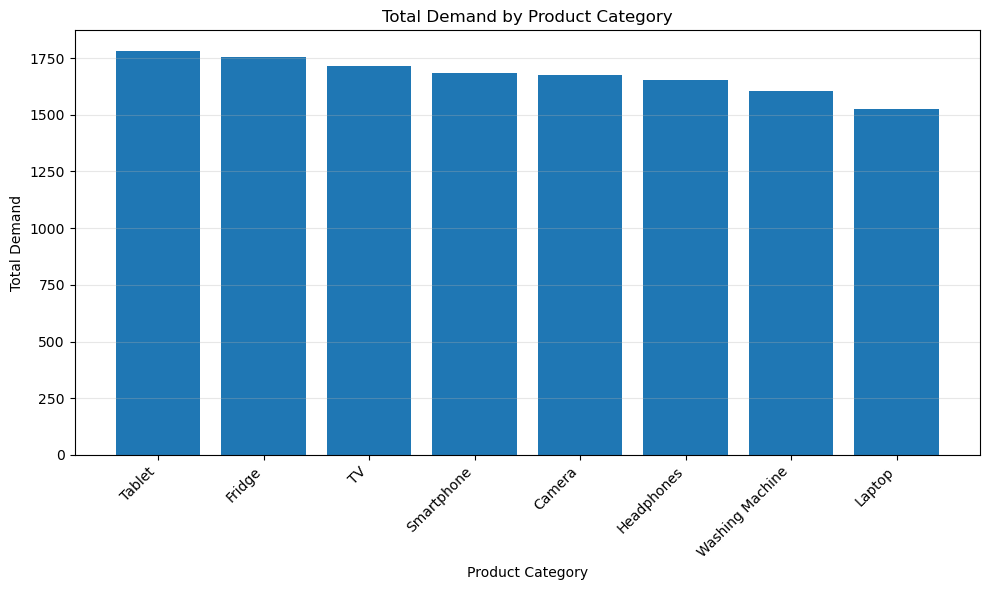

In [63]:
# =========================
# TOTAL DEMAND BY PRODUCT CATEGORY
# =========================

import matplotlib.pyplot as plt

# Aggregate demand per product category
product_demand = final_df.groupby('product_name')['demand'].sum().reset_index()

# Sort descending for clearer visualization
product_demand = product_demand.sort_values(by='demand', ascending=False)

# =========================
# PLOT
# =========================

plt.figure(figsize=(10,6))

plt.bar(
    product_demand['product_name'],
    product_demand['demand'],
    color='#1f77b4'  # consistent color (blue for demand)
)

# Labels (UPDATED FOR CONSISTENCY)
plt.title("Total Demand by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Demand")

# Rotate labels
plt.xticks(rotation=45, ha='right')

# Grid
plt.grid(axis='y', alpha=0.3)

# Layout
plt.tight_layout()

# Show
plt.show()

In [66]:
# =========================
# LSTM MODEL (FINAL)
# =========================

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# PREPARE TIME SERIES
# =========================

# Aggregate across products (for LSTM stability)
ts_data = final_df.groupby('week')['demand'].sum().sort_index()

# Scale data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(ts_data.values.reshape(-1,1))

# =========================
# CREATE SEQUENCES
# =========================

def create_sequences(data, seq_length=4):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, seq_length=4)

# =========================
# TRAIN-TEST SPLIT
# =========================

split = int(len(X) * 0.7)

X_train, X_test = X[:split], X[split:]
y_train, y_test_lstm = y[:split], y[split:]

# =========================
# BUILD LSTM MODEL
# =========================

model = Sequential()
model.add(LSTM(32, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# Train
model.fit(X_train, y_train, epochs=20, verbose=0)

# =========================
# PREDICT
# =========================

pred_lstm = model.predict(X_test)

# Inverse scaling
pred_lstm = scaler.inverse_transform(pred_lstm)
y_test_lstm = scaler.inverse_transform(y_test_lstm)

# =========================
# EVALUATE
# =========================

mae_lstm = mean_absolute_error(y_test_lstm, pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm, pred_lstm))
mape_lstm = np.mean(np.abs((y_test_lstm - pred_lstm) / (y_test_lstm + 1e-8))) * 100

print("LSTM Results:")
print("MAE:", round(mae_lstm, 3))
print("RMSE:", round(rmse_lstm, 3))
print("MAPE:", round(mape_lstm, 3))

C:\Users\mcasa\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
LSTM Results:
MAE: 233.31
RMSE: 239.816
MAPE: 72.044


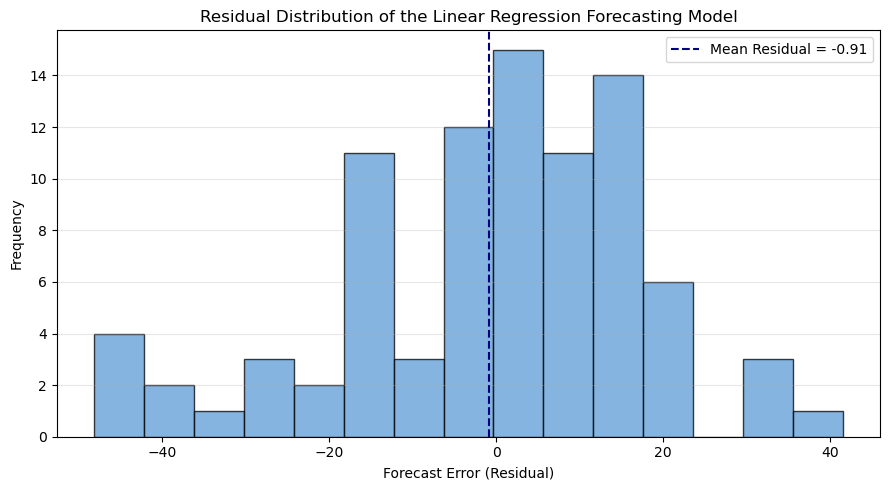

In [73]:
# Residuals
residuals = results_df['error']

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.hist(
    residuals,
    bins=15,
    color="#5B9BD5",
    edgecolor="black",
    alpha=0.75
)

mean_residual = residuals.mean()

plt.axvline(
    mean_residual,
    color="navy",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean Residual = {mean_residual:.2f}"
)

plt.title("Residual Distribution of the Linear Regression Forecasting Model")

plt.xlabel("Forecast Error (Residual)")
plt.ylabel("Frequency")

plt.grid(axis="y", alpha=0.30)

plt.legend()

plt.tight_layout()

plt.show()

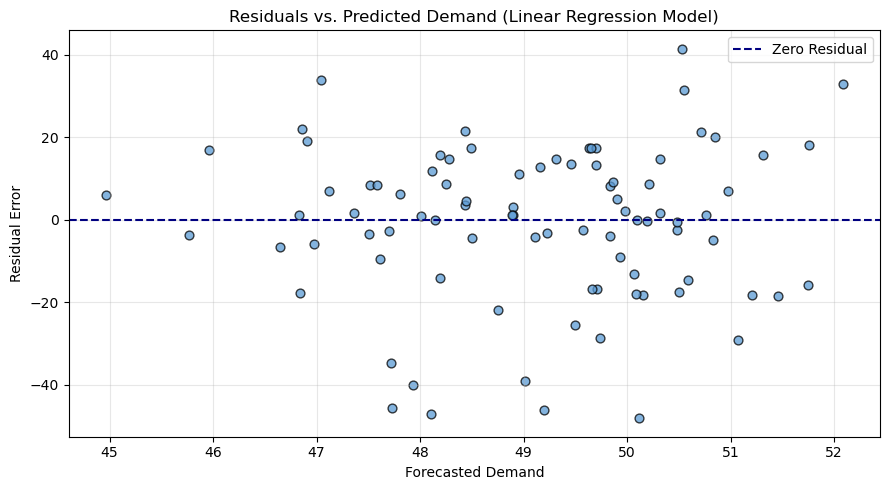

In [75]:
# ============================================
# APPENDIX A
# RESIDUALS vs PREDICTED DEMAND
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

# Scatter plot
plt.scatter(
    results_df['prediction'],
    results_df['error'],
    color="#5B9BD5",
    alpha=0.75,
    edgecolors='black',
    s=40
)

# Zero residual reference line
plt.axhline(
    y=0,
    color="navy",
    linestyle="--",
    linewidth=1.5,
    label="Zero Residual"
)

# Labels
plt.title(
    "Residuals vs. Predicted Demand (Linear Regression Model)",
    fontsize=12
)

plt.xlabel("Forecasted Demand")
plt.ylabel("Residual Error")

# Grid
plt.grid(alpha=0.30)

# Legend
plt.legend()

plt.tight_layout()

plt.show()